# INFO-F-422 NARX project

Statistical Foundations of Machine Learning · ULB · 2025-2026
Project notebook, team 37.

We learn a MIMO NARX model from the training pair $(\mathbf{U}^{tr}, \mathbf{Y}^{tr})$
and predict the two unseen test inputs $\mathbf{U}^{ts1}$ and $\mathbf{U}^{ts2}$.
The methodology is first developed and validated on two pilot NARXs
(eq. (5) and eq. (6) of the brief) for which the dynamics are known,
then deployed on the unknown system.

### NARX model (project spec, eq. (1))

$$
y_j(k+1) = f_j\!\Big( y_1(k-d), \ldots, y_1(k-d-n_a),\;
                       y_2(k-d), \ldots, y_2(k-d-n_a),
                       u_1(k), \ldots, u_1(k-n_b),\;
                       u_2(k), \ldots, u_2(k-n_b) \Big) + w_j(k+1)
$$

with $w_1, w_2 \sim \mathcal{N}(0, \sigma^2)$ i.i.d. The brief's
test-time initial-condition assumption is $y_1(0)=y_2(0)=u_1(0)=u_2(0)=0$
and all earlier values zero.

## 0. Setup

In [2]:
import os, sys, pathlib, warnings

# Walk up from the notebook's directory until we find the repo root,
# put src/ on the import path, and chdir there so relative paths work.
_here = pathlib.Path.cwd().resolve()
for cand in [_here, *_here.parents]:
    if (cand / 'src').is_dir() and (cand / 'data').is_dir():
        ROOT = cand
        break
else:
    raise RuntimeError('cannot find repo root')

if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RNG_SEED = 42

### Loading the project dataset

The four arrays we are given (each shape $(1000, 2)$):

| key   | role                                           |
|-------|------------------------------------------------|
| Utr   | training inputs $u_1, u_2$                     |
| Ytr   | training outputs $y_1, y_2$                    |
| Uts1  | first test input, used for the leaderboard    |
| Uts2  | second test input, used for the project mark  |

We cast everything to `float64` since `Ytr` and `Uts2` arrive as float32.

In [3]:
data = np.load('data/StudentdataNARX.npz')
Utr  = data['Utr'].astype(np.float64)
Ytr  = data['Ytr'].astype(np.float64)
Uts1 = data['Uts1'].astype(np.float64)
Uts2 = data['Uts2'].astype(np.float64)

for name, arr in [('Utr', Utr), ('Ytr', Ytr), ('Uts1', Uts1), ('Uts2', Uts2)]:
    print(f'{name}: shape={arr.shape}, range=[{arr.min():+.3f}, {arr.max():+.3f}]')

Utr: shape=(1000, 2), range=[-2.369, +1.792]
Ytr: shape=(1000, 2), range=[-4.856, +1.950]
Uts1: shape=(1000, 2), range=[-2.145, +1.775]
Uts2: shape=(1000, 2), range=[-1.825, +1.536]


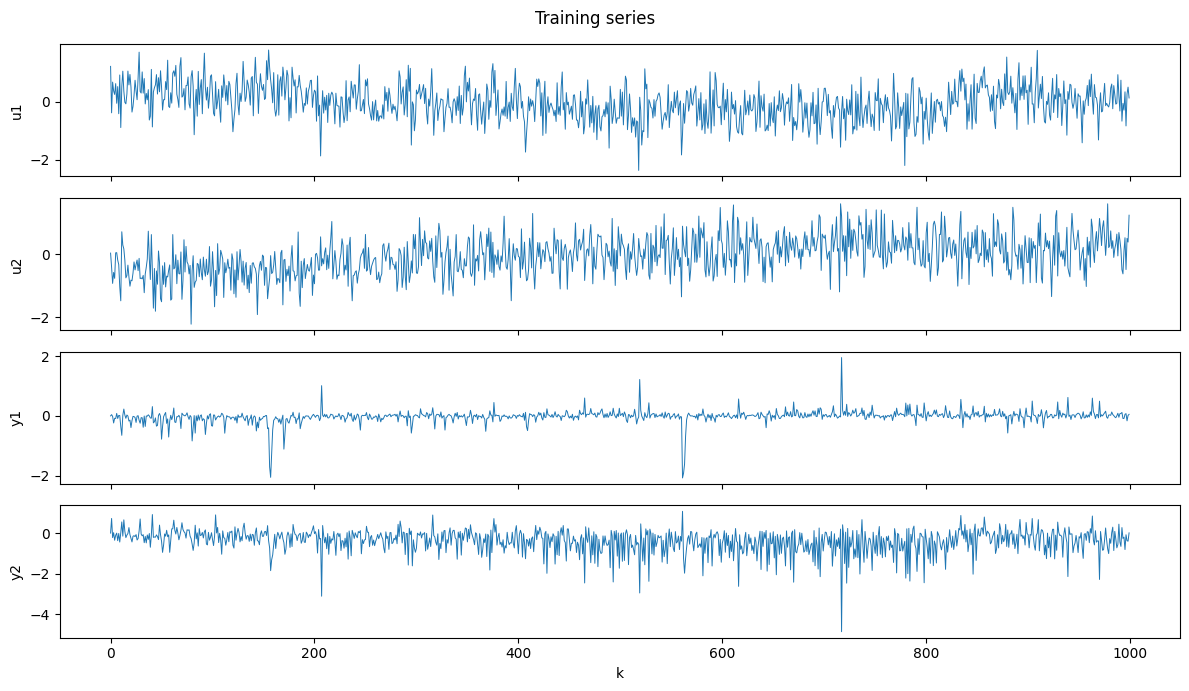

In [4]:
# Quick look at the four training series.
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax, arr, lbl in zip(axes,
                        [Utr[:, 0], Utr[:, 1], Ytr[:, 0], Ytr[:, 1]],
                        ['u1', 'u2', 'y1', 'y2']):
    ax.plot(arr, lw=0.7)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel('k')
fig.suptitle('Training series')
plt.tight_layout()
plt.show()

## 1. Pilot simulators (Task 1)

The two pilots in §3 of the brief have closed-form dynamics, so we can
use them as known ground-truth systems to validate every step of the
pipeline (lag selection, fitting, multi-step prediction) before
betting anything on the unknown training data.

### 1.1 NARX1: single input, two coupled outputs

$$
\begin{aligned}
y_1(k{+}1) &= 0.5\, y_2(k{-}1) + \sin\bigl(y_2(k)\bigr) + 0.3\, u(k{-}1) + w_1(k{+}1)\\
y_2(k{+}1) &= 0.5\, y_1(k{-}1) + \sin\bigl(y_1(k)\bigr) + 0.2\, u(k)   + w_2(k{+}1)
\end{aligned}
$$

Reading the equation directly: $y_1(k{+}1)$ and $y_2(k{+}1)$ both need
the previous output at lags $0$ and $1$, and $u$ at lags $0$ and $1$.
True structural parameters are therefore $d{=}0$, $n_a{=}1$, $n_b{=}1$.

In [5]:
from narx.simulators import (simulate_narx1, simulate_narx2,
                               NARX1_TRUE_PARAMS, NARX2_TRUE_PARAMS)

# Pilot lengths matching the real data (1000 train, 1000 test) so the
# methodology validation runs on a regime comparable to what we'll
# encounter at deployment.
N_tr, N_ts = 1000, 1000
U1tr, Y1tr, U1ts, Y1ts = simulate_narx1(N_tr, N_ts, sigma=0.05, seed=RNG_SEED)
U2tr, Y2tr, U2ts, Y2ts = simulate_narx2(N_tr, N_ts, sigma=0.01, seed=RNG_SEED)

print(f'NARX1: train U{U1tr.shape} Y{Y1tr.shape}  test U{U1ts.shape} Y{Y1ts.shape}')
print(f'NARX2: train U{U2tr.shape} Y{Y2tr.shape}  test U{U2ts.shape} Y{Y2ts.shape}')

NARX1: train U(1000, 2) Y(1000, 2)  test U(1000, 2) Y(1000, 2)
NARX2: train U(1000, 2) Y(1000, 2)  test U(1000, 2) Y(1000, 2)


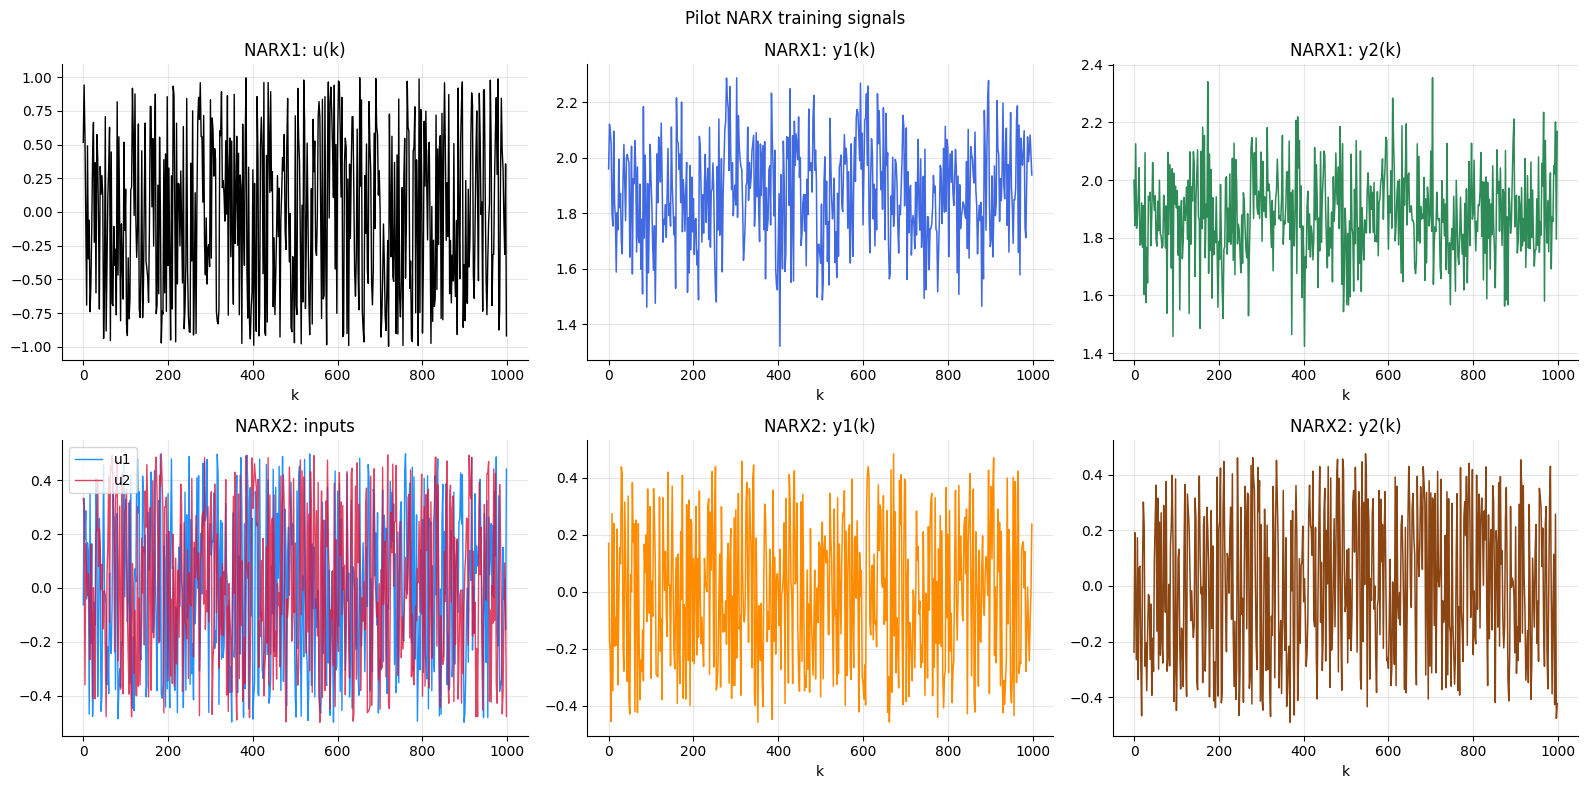

In [6]:
# Pilot training signals at a glance.
def stylize(ax):
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

step = 2
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Pilot NARX training signals')

k1 = np.arange(len(U1tr))
axes[0, 0].plot(k1[::step], U1tr[::step, 0], lw=1.0, color='black')
axes[0, 0].set_title('NARX1: u(k)'); axes[0, 0].set_xlabel('k'); stylize(axes[0, 0])
axes[0, 1].plot(k1[::step], Y1tr[::step, 0], lw=1.1, color='royalblue')
axes[0, 1].set_title('NARX1: y1(k)'); axes[0, 1].set_xlabel('k'); stylize(axes[0, 1])
axes[0, 2].plot(k1[::step], Y1tr[::step, 1], lw=1.1, color='seagreen')
axes[0, 2].set_title('NARX1: y2(k)'); axes[0, 2].set_xlabel('k'); stylize(axes[0, 2])

k2 = np.arange(len(U2tr))
axes[1, 0].plot(k2[::step], U2tr[::step, 0], lw=1.0, color='dodgerblue', label='u1')
axes[1, 0].plot(k2[::step], U2tr[::step, 1], lw=1.0, color='crimson', alpha=0.8, label='u2')
axes[1, 0].set_title('NARX2: inputs'); axes[1, 0].legend(); stylize(axes[1, 0])
axes[1, 1].plot(k2[::step], Y2tr[::step, 0], lw=1.1, color='darkorange')
axes[1, 1].set_title('NARX2: y1(k)'); axes[1, 1].set_xlabel('k'); stylize(axes[1, 1])
axes[1, 2].plot(k2[::step], Y2tr[::step, 1], lw=1.1, color='saddlebrown')
axes[1, 2].set_title('NARX2: y2(k)'); axes[1, 2].set_xlabel('k'); stylize(axes[1, 2])

plt.tight_layout(); plt.show()

### 1.2 NARX2: two inputs, rational nonlinearity

$$
\begin{aligned}
y_1(k{+}1) &= \frac{y_1(k)\,y_1(k{-}1)\,y_1(k{-}2)\,\bigl(y_1(k{-}2){-}1\bigr)\,u_2(k{-}1) + u_2(k)}{1 + y_2(k{-}1)^2 + y_2(k{-}2)^2} + w_1(k{+}1)\\[6pt]
y_2(k{+}1) &= \frac{y_2(k)\,y_2(k{-}1)\,y_2(k{-}2)\,\bigl(y_2(k{-}2){-}1\bigr)\,u_1(k{-}1) + u_1(k)}{1 + y_1(k{-}1)^2 + y_1(k{-}2)^2} + w_2(k{+}1)
\end{aligned}
$$

Three output lags appear (deepest is $y(k{-}2)$) and $u$ at lags $0,1$.
True structural parameters: $d{=}0$, $n_a{=}2$, $n_b{=}1$.
We squeeze the input range to $[-0.5, 0.5]$ so the rational map stays
well-behaved near the origin.

### 1.3 ACF diagnostics

The ACF of each output gives a cheap visual prior on the lag structure
before we run the full grid in §2a. A geometric decay points at AR-like
behaviour ($n_a$ can be modest); a sharp cutoff at lag $L$ would suggest
a moving-average-like structure with $n_a \approx L$.

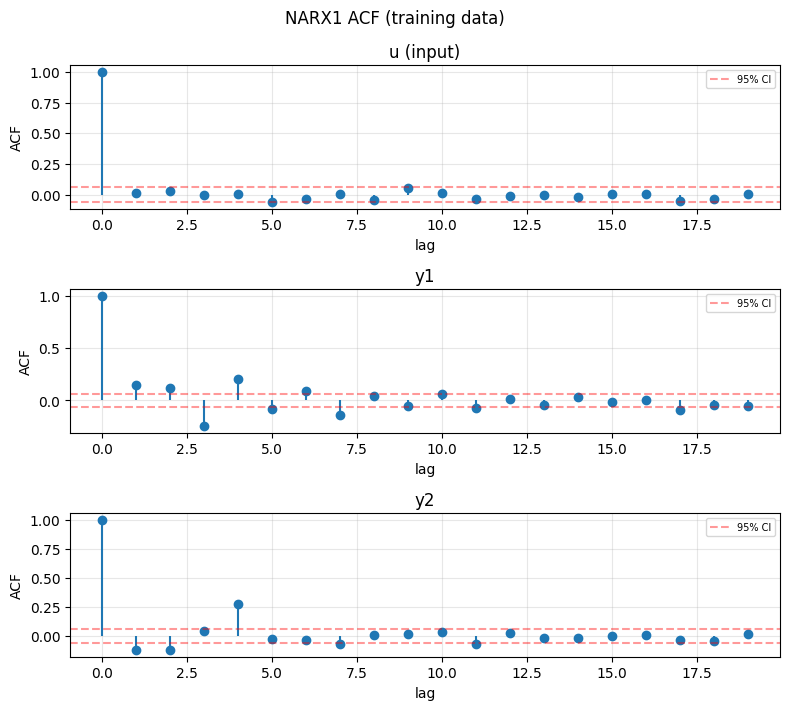

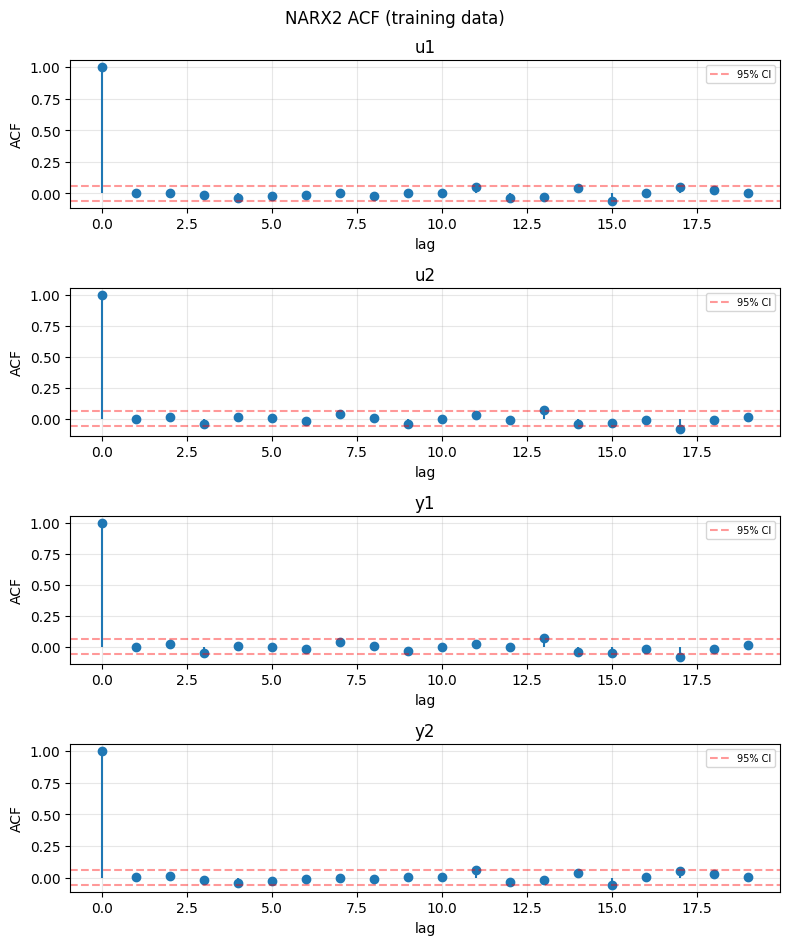

In [7]:
# ACF helper that doesn't pull in statsmodels (kept simple on purpose).
def plot_autocorr(signals, names, max_lag=20, title=''):
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.4 * n))
    if n == 1:
        axes = [axes]
    for ax, sig, name in zip(axes, signals, names):
        sig = np.asarray(sig).ravel()
        sig = sig - sig.mean()
        acf = np.correlate(sig, sig, mode='full')
        acf = acf[acf.size // 2:]
        acf /= acf[0]
        ax.stem(range(max_lag), acf[:max_lag], basefmt=' ')
        ci = 1.96 / np.sqrt(len(sig))
        ax.axhline( ci, ls='--', color='red', alpha=0.4, label='95% CI')
        ax.axhline(-ci, ls='--', color='red', alpha=0.4)
        ax.set_title(name); ax.set_xlabel('lag'); ax.set_ylabel('ACF')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_autocorr([U1tr[:, 0], Y1tr[:, 0], Y1tr[:, 1]],
              ['u (input)', 'y1', 'y2'], max_lag=20,
              title='NARX1 ACF (training data)')

plot_autocorr([U2tr[:, 0], U2tr[:, 1], Y2tr[:, 0], Y2tr[:, 1]],
              ['u1', 'u2', 'y1', 'y2'], max_lag=20,
              title='NARX2 ACF (training data)')

## 2. Learning the dynamics (Task 2)

### 2a. Parameter selection (d, na, nb)

$d$, $n_a$, $n_b$ are discrete structural hyperparameters; no gradient
is available so we run a grid search and score each candidate with
time-series cross-validation. We use `TimeSeriesSplit` rather than
`KFold` because shuffling a time series mixes cold-start transients
with settled-regime samples across the train/val splits, which is the
kind of leakage Ljung's *System Identification* (1999, §16) warns
about.

Each candidate triple is scored under five proxy models (Gradient
Boosting, Random Forest, Extra Trees, XGBoost, plus a Ridge on a
hand-engineered nonlinear expansion: $\sin x$, $x^2$, $x^3$,
pairwise products). One vote per proxy for its own argmin triple,
majority wins, ties broken by mean score across proxies. The full
loop lives in `grid_search` in `lag_selection.py`.

In [ ]:
from narx.lag_selection import grid_search, plot_proxy_comparison

best_params_narx1, all_results_narx1 = grid_search(
    Y1tr, U1tr,
    d_range=[0, 1], na_range=[0, 1, 2, 3], nb_range=[0, 1, 2, 3],
    label='NARX1', verbose=False, n_splits=3,
)
print('NARX1 picked', best_params_narx1, ', true:', NARX1_TRUE_PARAMS)

In [ ]:
best_params_narx2, all_results_narx2 = grid_search(
    Y2tr, U2tr,
    d_range=[0, 1], na_range=[0, 1, 2, 3], nb_range=[0, 1, 2, 3],
    label='NARX2', verbose=False, n_splits=3,
)
print('NARX2 picked', best_params_narx2, ', true:', NARX2_TRUE_PARAMS)

In [ ]:
plot_proxy_comparison(all_results_narx1, label='NARX1', d_fixed=best_params_narx1[0])
plt.show()
plot_proxy_comparison(all_results_narx2, label='NARX2', d_fixed=best_params_narx2[0])
plt.show()

### 2b. MIMO and multi-step-ahead strategy

The grading test horizon is $H = 1000$ steps and we must produce both
outputs $\hat y_1, \hat y_2$ jointly. The four canonical strategies
are summarised in Bontempi et al. 2013, *Machine Learning Strategies
for Time Series Forecasting* (§4):

| strategy | one-shot? | error compounds? | feasible at H=1000? |
|---|---|---|---|
| Recursive (iterated) | no, step by step | yes, every step | yes, but drifts |
| Direct | one model per horizon | no | no, 1000 models |
| DirRec | hybrid | partial | borderline |
| MIMO direct (vector) | one block of size $H$ | no within block | no, too long |
| **DIRMO** | $\lceil H/s \rceil$ blocks of size $s$ | only across blocks | yes |

We adopt DIRMO with block size $s$ tuned on data (Bontempi et al.
2013, §4.3). Inside one block the $s$ predictions come from one
forward pass on $\phi(k_b)$, so they don't compound; errors propagate
only across the block boundaries, and the effective amplification
drops by a factor of roughly $s$ vs pure recursive ($s{=}1$). Both
outputs are predicted jointly via `MultiOutputRegressor` (one fitted
regressor per scalar target, shared regressor matrix) so for a given
$s$ we end up with $s \times n_y$ regressors.

A known failure mode of the recursive rollout is the train/test
mismatch: at training the model sees clean past $y$, but at inference
it sees its own noisy predictions. To soften this issue we inject
Gaussian noise on output regressors at training (Bengio et al. 2015,
*Scheduled Sampling*) and we sweep its scale below.

In [ ]:
# Sigma-y noise injection sweep on NARX1, using the same
# Pipeline(scaler, MultiOutputRegressor(GB)) we adopt in §2c.
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from narx.features import independent_matrix
from narx.recursive import recursive_predict, evaluate_rollout

rng = np.random.default_rng(42)
y_std_train = Y1tr.std(axis=0).mean()
d, na, nb = NARX1_TRUE_PARAMS['d'], NARX1_TRUE_PARAMS['na'], NARX1_TRUE_PARAMS['nb']
gb_proto = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                      learning_rate=0.1, subsample=0.8,
                                      random_state=42)

for sigma_frac in [0.0, 0.05, 0.10, 0.20]:
    sigma_y = sigma_frac * y_std_train
    X, T = independent_matrix(Y1tr, U1tr, d, na, nb, sigma_y=sigma_y, rng=rng)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('estimator', MultiOutputRegressor(clone(gb_proto))),
    ]).fit(X, T)
    Y_hat = recursive_predict(pipe, U1ts, d, na, nb,
                                y_mean=Y1tr.mean(0), y_std=Y1tr.std(0))
    evaluate_rollout(Y1ts, Y_hat, label=f'NARX1 sigma_y={sigma_frac:.2f}*sigma')
    plt.show()

In [ ]:
# DIRMO block-size sweep on NARX2.
from narx.dirmo import compare_block_sizes, plot_dirmo_results

d, na, nb = NARX2_TRUE_PARAMS['d'], NARX2_TRUE_PARAMS['na'], NARX2_TRUE_PARAMS['nb']
base_gb = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                     learning_rate=0.05, subsample=0.8,
                                     random_state=42)

block_sizes = (1, 2, 5, 10, 20, 30, 50, 80)
results_narx2 = compare_block_sizes(
    Y2tr, U2tr, Y2ts, U2ts,
    d=d, na=na, nb=nb,
    base_model=base_gb,
    block_sizes=block_sizes,
)
plot_dirmo_results(results_narx2, Y2ts, block_sizes=block_sizes, label='NARX2')
plt.show()